In [ ]:
import requests
import pandas as pd
from io import StringIO
import re
import time
from google.colab import files

# DEFINE THE MASTER SCRAPING ENGINE

def scrape_country_universities(country):
    # Format the URL (e.g., "United Kingdom" becomes "United_Kingdom")
    formatted_country = country.replace(" ", "_")
    url = f"https://en.wikipedia.org/wiki/List_of_universities_in_{formatted_country}"

    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) DataAnalystPortfolio/2.0"}

    try:
        response = requests.get(url, headers=headers)
        # If the page doesn't exist (404), skip it gracefully
        if response.status_code != 200:
            print(f"  [Skip] No standard Wikipedia list found for {country}.")
            return pd.DataFrame()

        tables = pd.read_html(StringIO(response.text))

    except Exception as e:
        print(f"  [Error] Could not process {country}: {e}")
        return pd.DataFrame()

    target_df = None
    for df in tables:
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = [col[-1] for col in df.columns]

        cols = [str(c).lower() for c in df.columns]

        # Broadened search: look for name/institution AND establish/found/opened
        has_name = any(kw in c for c in cols for kw in ['university', 'name', 'institution'])
        has_year = any(kw in c for c in cols for kw in ['establish', 'found', 'opened'])

        if has_name and has_year:
            target_df = df
            break

    if target_df is None:
        print(f"  [Skip] No compatible table structure found on the page for {country}.")
        return pd.DataFrame()

    # Extract the exact column names
    name_col = next(c for c in target_df.columns if any(kw in str(c).lower() for kw in ['university', 'name', 'institution']))
    year_col = next(c for c in target_df.columns if any(kw in str(c).lower() for kw in ['establish', 'found', 'opened']))

    clean_df = pd.DataFrame()
    clean_df['University Name'] = target_df[name_col]
    clean_df['Established Year'] = target_df[year_col]
    clean_df['Country'] = country

    print(f"  [Success] Scraped {len(clean_df)} universities for {country}.")
    return clean_df

#  LIST OF EUROPEAN COUNTRIES
european_countries = [
    "Albania", "Austria", "Belarus", "Belgium", "Bosnia and Herzegovina",
    "Bulgaria", "Croatia", "Cyprus", "Czech Republic", "Denmark", "Estonia",
    "Finland", "France", "Germany", "Greece", "Hungary", "Iceland", "Ireland",
    "Italy", "Latvia", "Lithuania", "Luxembourg", "Malta", "Moldova", "Montenegro",
    "Netherlands", "North Macedonia", "Norway", "Poland", "Portugal", "Romania",
    "Serbia", "Slovakia", "Slovenia", "Spain", "Sweden", "Switzerland", "Ukraine",
    "United Kingdom"
]

#  EXECUTE THE LOOP WITH RATE LIMITING
print("Starting Pan-European University Scrape...\n")
all_dataframes = []

for country in european_countries:
    df = scrape_country_universities(country)
    if not df.empty:
        all_dataframes.append(df)
    # Pause for 1.5 seconds to avoid being blocked by Wikipedia
    time.sleep(1.5)

# Combine everything into one massive dataset
df_master = pd.concat(all_dataframes, ignore_index=True)

#  DATA CLEANING
print("\nCleaning the pan-European dataset...")

def clean_text(text):
    if pd.isna(text): return text
    text = re.sub(r'\[.*?\]', '', str(text)) # Remove citations like [1]
    return text.strip()

def extract_year(text):
    if pd.isna(text): return None
    match = re.search(r'\b(1\d{3}|20[0-2]\d)\b', str(text)) # Extract valid years (1000-2029)
    return int(match.group(1)) if match else None

df_master['University Name'] = df_master['University Name'].apply(clean_text)
df_master['Established Year'] = df_master['Established Year'].apply(extract_year)

# Drop missing values and convert years to integers
df_master = df_master.dropna(subset=['University Name', 'Established Year']).copy()
df_master['Established Year'] = df_master['Established Year'].astype(int)

#  EXPORT AND DOWNLOAD
filename = 'all_europe_academic_landscape.csv'
df_master.to_csv(filename, index=False)
print(f"\nScraping complete! Total universities mapped: {len(df_master)}")
print(f"Downloading '{filename}' to your computer for Power BI...")

# Trigger browser download
files.download(filename)

# Preview the first and last few rows
display(df_master)

Starting Pan-European University Scrape...

  [Skip] No compatible table structure found on the page for Albania.
  [Success] Scraped 77 universities for Austria.
  [Skip] No compatible table structure found on the page for Belarus.
  [Skip] No compatible table structure found on the page for Belgium.
  [Success] Scraped 8 universities for Bosnia and Herzegovina.
  [Skip] No compatible table structure found on the page for Bulgaria.
  [Skip] No compatible table structure found on the page for Croatia.
  [Skip] No compatible table structure found on the page for Cyprus.
  [Skip] No standard Wikipedia list found for Czech Republic.
  [Skip] No compatible table structure found on the page for Denmark.
  [Skip] No compatible table structure found on the page for Estonia.
  [Success] Scraped 11 universities for Finland.
  [Skip] No compatible table structure found on the page for France.
  [Success] Scraped 124 universities for Germany.
  [Skip] No compatible table structure found on the pa

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,University Name,Established Year,Country
0,Academy of Fine Arts Vienna,1692,Austria
1,University of Applied Arts Vienna,1867,Austria
2,Anton Bruckner Private University,2004,Austria
3,Bertha von Suttner Private University,2018,Austria
4,University of Natural Resources and Life Scien...,1872,Austria
...,...,...,...
401,Università della Svizzera Italiana,1995,Switzerland
402,University of St. Gallen,1898,Switzerland
403,University of Zurich,1833,Switzerland
404,Swiss Federal Institute of Technology Lausanne,1853,Switzerland


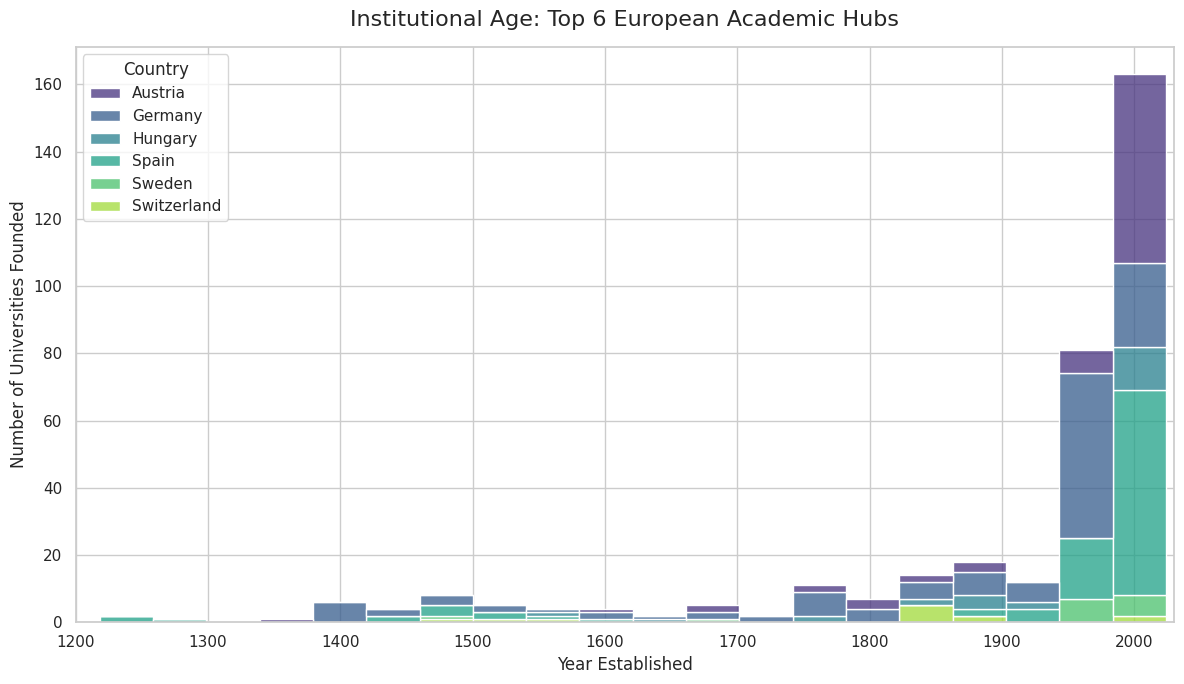

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#  Load the pan-European dataset
df_master = pd.read_csv('all_europe_academic_landscape.csv')

#  Filter for readability
# Grab the names of the 6 countries with the most universities
top_countries = df_master['Country'].value_counts().head(6).index

# Create a new DataFrame containing only those top 6 countries
df_filtered = df_master[df_master['Country'].isin(top_countries)]

#  Visualization
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

#  Create the Stacked Histogram
sns.histplot(
    data=df_filtered,
    x='Established Year',
    hue='Country',           # Color-code by country
    multiple='stack',        # Stack the bars on top of each other
    bins=20,                 # Group years into 20 historical buckets
    palette='viridis',       # Professional color palette
    edgecolor='white'        # Add white lines between stacks for clarity
)

# 5. Formatting and Labels
plt.title('Institutional Age: Top 6 European Academic Hubs', fontsize=16, pad=15)
plt.xlabel('Year Established', fontsize=12)
plt.ylabel('Number of Universities Founded', fontsize=12)
plt.xlim(1200, 2030) # Crop the timeline to standard historical bounds

# Ensure everything fits cleanly
plt.tight_layout()

# Render the chart
plt.show()